In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
import torch # Import the torch module
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


df = pd.read_excel("New Final DataSet.xlsx", engine='openpyxl')


# Select only numerical columns for scaling
columns_to_scale =['N','P','K','S','pH','Temp(°C)','Humidity(%)','Moisture(%)','Rainfall(cm)']

scaler = MinMaxScaler()

# Apply scaling to the selected columns and assign them back to the DataFrame
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

label_encoder = LabelEncoder()

# Encode categorical columns
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)
x = df_scaled.drop(columns = ['label_encoded'])

y = df_scaled['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, stratify=y, random_state=42)

In [ ]:
import torch
from torch.utils.data import DataLoader, Dataset

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)  # Use long for classification

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create Dataset objects
train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class CropCNN(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size):
        super(CropCNN, self).__init__()
        self.convs = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_channels = 1  # Tabular data reshaped to (1, 3, 3)

        # Compute the final output size after convolutions
        height, width = input_shape[1], input_shape[2]

        for _ in range(num_layers):
            padding = (kernel_size - 1) // 2  # Same padding
            self.convs.append(nn.Conv2d(in_channels, init_channels, kernel_size, padding=padding))
            self.pools.append(nn.MaxPool2d(2))  # Add pooling after convolution
            in_channels = init_channels
            init_channels *= 2  # Double channels with each layer

            # Update height and width after each convolution
            height = (height - kernel_size + 2 * padding) + 1
            width = (width - kernel_size + 2 * padding) + 1
            height = height // 2  # After pooling
            width = width // 2    # After pooling

            # Avoid too much shrinking
            if height <= 1 or width <= 1:
                break  # Stop if the size shrinks too much

        # After the final convolution layer, calculate the flattened size
        self.flattened_size = in_channels * height * width
        self.fc = nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        for conv, pool in zip(self.convs, self.pools):
            x = F.relu(conv(x))
            x = pool(x)  # Apply max pooling
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x


In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.0 MB/s eta 0:00:00


In [ ]:
import optuna
import torch
import numpy as np
from torch.optim import Adam
from sklearn.preprocessing import LabelEncoder

# Set seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Objective function for Optuna optimization
def objective(trial):
    # Hyperparameter search space
    num_layers = trial.suggest_int("num_layers", 1, 5)
    init_channels = trial.suggest_int("init_channels", 16, 64, step=16)
    kernel_size = trial.suggest_int("kernel_size", 2, 3)
    learning_rate = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    epochs = trial.suggest_int("epochs", 5, 30)  # Optimize the number of epochs as well

    # Model, Loss, Optimizer
    model = CropCNN(input_shape=(1, 3, 3), num_classes=len(label_encoder.classes_),
                    num_layers=num_layers, init_channels=init_channels, kernel_size=kernel_size)
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.view(-1, 1, 3, 3)  # Reshape for CNN
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.view(-1, 1, 3, 3)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

    accuracy = correct / total
    return accuracy

# Set verbosity to suppress logs if desired
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Optional: To suppress logs

# Create and optimize the study
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Print the best hyperparameters found
print("Best hyperparameters:", study.best_params)


Best hyperparameters: {'num_layers': 3, 'init_channels': 48, 'kernel_size': 2, 'lr': 0.008718700778837032, 'epochs': 30}


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class CropCNN(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers=3, init_channels=48, kernel_size=2):
        super(CropCNN, self).__init__()
        self.convs = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_channels = 1  # Tabular data reshaped to (1, 3, 3)

        # Compute the final output size after convolutions
        height, width = input_shape[1], input_shape[2]

        for _ in range(num_layers):
            padding = (kernel_size - 1) // 2  # Same padding
            self.convs.append(nn.Conv2d(in_channels, init_channels, kernel_size, padding=padding))
            self.pools.append(nn.MaxPool2d(2))  # Add pooling after convolution
            in_channels = init_channels
            init_channels *= 2  # Double channels with each layer

            # Update height and width after each convolution
            height = (height - kernel_size + 2 * padding) + 1
            width = (width - kernel_size + 2 * padding) + 1
            height = height // 2  # After pooling
            width = width // 2    # After pooling

            # Avoid too much shrinking
            if height <= 1 or width <= 1:
                break  # Stop if the size shrinks too much

        # After the final convolution layer, calculate the flattened size
        self.flattened_size = in_channels * height * width
        self.fc = nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        for conv, pool in zip(self.convs, self.pools):
            x = F.relu(conv(x))
            x = pool(x)  # Apply max pooling
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x

# Instantiate the model
num_classes = 22  # Based on your dataset
model = CropCNN(input_shape=(1, 3, 3), num_classes=num_classes,
                num_layers=3, init_channels=48, kernel_size=2)

# Print model architecture to verify
print(model)


CropCNN(
  (convs): ModuleList(
    (0): Conv2d(1, 48, kernel_size=(2, 2), stride=(1, 1))
  )
  (pools): ModuleList(
    (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=48, out_features=22, bias=True)
)


Epoch 1/30, Loss: 2.7287, Train Accuracy: 0.2174, Test Accuracy: 0.4258
Epoch 2/30, Loss: 1.7458, Train Accuracy: 0.5701, Test Accuracy: 0.7091
Epoch 3/30, Loss: 1.0932, Train Accuracy: 0.7409, Test Accuracy: 0.7712
Epoch 4/30, Loss: 0.8010, Train Accuracy: 0.7970, Test Accuracy: 0.7939
Epoch 5/30, Loss: 0.6563, Train Accuracy: 0.8254, Test Accuracy: 0.7985
Epoch 6/30, Loss: 0.5714, Train Accuracy: 0.8417, Test Accuracy: 0.8273
Epoch 7/30, Loss: 0.5013, Train Accuracy: 0.8606, Test Accuracy: 0.8379
Epoch 8/30, Loss: 0.4697, Train Accuracy: 0.8625, Test Accuracy: 0.8364
Epoch 9/30, Loss: 0.4337, Train Accuracy: 0.8742, Test Accuracy: 0.8606
Epoch 10/30, Loss: 0.4067, Train Accuracy: 0.8792, Test Accuracy: 0.8727
Epoch 11/30, Loss: 0.3910, Train Accuracy: 0.8826, Test Accuracy: 0.8712
Epoch 12/30, Loss: 0.3670, Train Accuracy: 0.8909, Test Accuracy: 0.8667
Epoch 13/30, Loss: 0.3581, Train Accuracy: 0.8890, Test Accuracy: 0.8727
Epoch 14/30, Loss: 0.3502, Train Accuracy: 0.8852, Test Accu

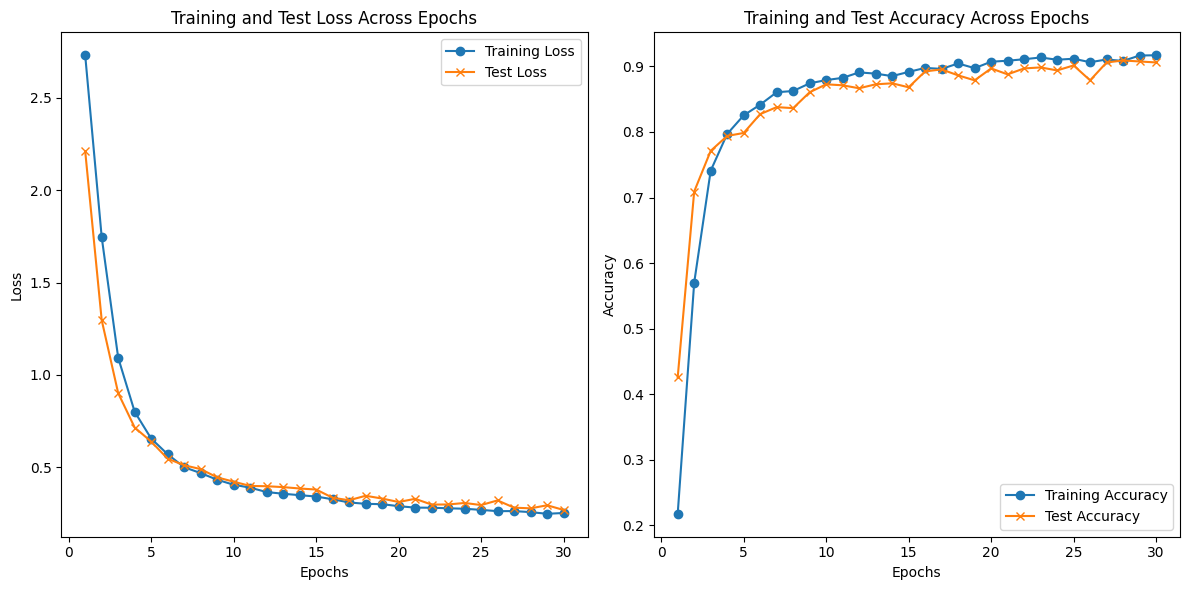

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)


# Define your model
model = CropCNN(input_shape=(1, 3, 3), num_classes=22, num_layers=3, init_channels=48, kernel_size=2)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0087)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Training loop
epochs = 30
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

best_test_accuracy = 0
best_epoch = 0
best_preds = []
best_targets = []
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    correct_train = 0
    total_train = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.view(-1, 1, 3, 3).to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Calculate train accuracy
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()

    avg_loss = epoch_loss / len(train_loader)
    train_accuracy = correct_train / total_train
    train_losses.append(avg_loss)
    train_accuracies.append(train_accuracy)

    # Testing loop
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.view(-1, 1, 3, 3).to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

            # Calculate test accuracy
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()

    test_accuracy = correct_test / total_test
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_accuracy)

    # Track best test accuracy and its corresponding predictions/targets
    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy
        best_epoch = epoch + 1  # Epoch count starts from 0
        best_preds = all_preds
        best_targets = all_targets

    # Print train and test accuracies for the current epoch
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# After training, print the best results
print(f"\nBest Test Accuracy: {best_test_accuracy:.4f} at Epoch {best_epoch}")

# Classification report for the best epoch's test predictions
print("\nBest Epoch Classification Report:")
print(classification_report(best_targets, best_preds, target_names=label_encoder.classes_))

# Plot Training Loss and Test Loss across epochs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, epochs + 1), test_losses, marker='x', label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Across Epochs')
plt.legend()

# Plot Training Accuracy and Test Accuracy across epochs
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, marker='o', label='Training Accuracy')
plt.plot(range(1, epochs + 1), test_accuracies, marker='x', label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy Across Epochs')
plt.legend()

plt.tight_layout()
plt.show()


Without S

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 6.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import optuna

# Set random seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select numerical columns for scaling (remove 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Prepare features and labels
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Reshape X to 2x4 grid based on the number of features
X = X.reshape(-1, 1, 2, 4)  # Reshape into a 2x4 grid (8 features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert data to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN model (without BiLSTM)
class CropCNN(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size):
        super(CropCNN, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        # CNN layers
        for i in range(num_layers):
            in_channels = 1 if i == 0 else init_channels
            self.convs.append(
                nn.Conv2d(in_channels, init_channels, kernel_size=kernel_size, padding=1)
            )

        # Calculate the output size after passing through CNN layers
        self.conv_output_size = self._get_conv_output_size(input_shape)

        # Fully connected layer
        self.fc = nn.Linear(self.conv_output_size, num_classes)

    def _get_conv_output_size(self, input_shape):
        # Test a dummy input through the CNN layers to get the output size
        dummy_input = torch.zeros(1, *input_shape)
        x = dummy_input
        for conv in self.convs:
            x = F.relu(conv(x))
        return x.view(1, -1).size(1)  # Flatten and return the number of features

    def forward(self, x):
        for conv in self.convs:
            x = F.relu(conv(x))

        x = x.view(x.size(0), -1)  # Flatten before fully connected layer
        x = self.fc(x)
        return x

# Define Optuna objective function for CNN model
def objective(trial):
    num_layers = trial.suggest_int('num_layers', 1, 3)
    init_channels = trial.suggest_categorical('init_channels', [16, 32, 64])
    kernel_size = trial.suggest_int('kernel_size', 2, 3)
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    epochs = trial.suggest_int('epochs', 10, 30)

    model = CropCNN(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                    num_layers=num_layers, init_channels=init_channels,
                    kernel_size=kernel_size)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Validation Accuracy
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.tolist())
            all_targets.extend(y_batch.tolist())

    accuracy = accuracy_score(all_targets, all_predictions)
    return accuracy

# Run Optuna optimization
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Get the best parameters
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2025-01-18 16:48:08,874] A new study created in memory with name: no-name-4017bd56-4bc7-4524-a2d2-991b963f5369
<ipython-input-2-fdf3bfa58308>:90: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-01-18 16:48:25,327] Trial 0 finished with value: 0.7424242424242424 and parameters: {'num_layers': 2, 'init_channels': 16, 'kernel_size': 2, 'lr': 0.00020511104188433984, 'epochs': 11}. Best is trial 0 with value: 0.7424242424242424.
<ipython-input-2-fdf3bfa58308>:90: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-01-18 16:48:31,868] Trial 1 finished with value: 0.90151

Best hyperparameters: {'num_layers': 2, 'init_channels': 32, 'kernel_size': 2, 'lr': 0.008133728243728402, 'epochs': 25}


In [ ]:
Best hyperparameters: {'num_layers': 2, 'init_channels': 32, 'kernel_size': 2, 'lr': 0.003315013507098331, 'epochs': 25}



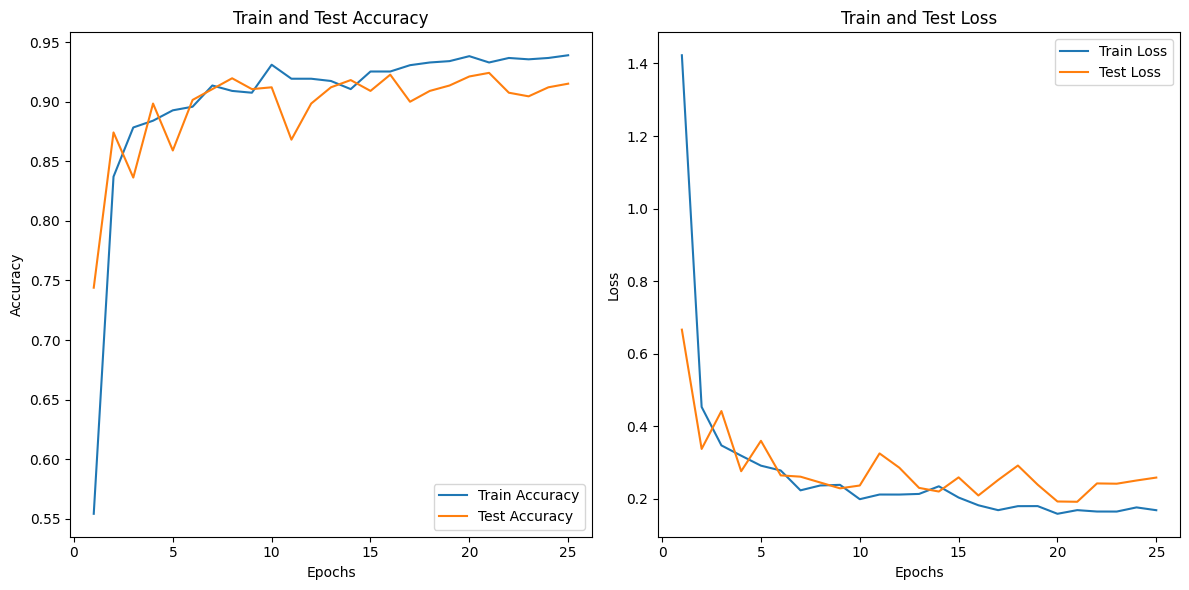

Epoch with Highest Test Accuracy: 21
Train Accuracy at Best Epoch: 0.9330
Test Accuracy at Best Epoch: 0.9242
Test Precision at Best Epoch: 0.8970
Test Recall at Best Epoch: 0.8961
Test F1-Score at Best Epoch: 0.8962


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.optim import Adam
import numpy as np

# Assuming best_params and data loaders are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Initialize model with best parameters
model = CropCNN(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                      num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                      kernel_size=best_params['kernel_size']
                      )

optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Track metrics for plotting
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []

# Ensure reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

# Training and evaluation loop
for epoch in range(best_params['epochs']):
    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnn.png', transparent=True)  # Save the plot as an image file
plt.show()

# Find the epoch with the highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Get the corresponding train and test accuracy for that epoch
best_train_accuracy = train_accuracies[best_epoch]
best_test_accuracy = test_accuracies[best_epoch]

# Calculate precision, recall, and F1-score for the best epoch
test_precision = precision_score(all_targets, all_predictions, average="macro", zero_division=1)
test_recall = recall_score(all_targets, all_predictions, average="macro", zero_division=1)
test_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=1)

# Print the results
print(f"Epoch with Highest Test Accuracy: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best Epoch: {best_test_accuracy:.4f}")
print(f"Test Precision at Best Epoch: {test_precision:.4f}")
print(f"Test Recall at Best Epoch: {test_recall:.4f}")
print(f"Test F1-Score at Best Epoch: {test_f1:.4f}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from sklearn.metrics import classification_report

# Assuming all_targets and all_predictions contain the true and predicted values for the entire validation set

# Generate the classification report
report = classification_report(all_targets, all_predictions, target_names=label_encoder.classes_,digits=3)

# Print the classification report
print("Classification Report:\n", report)

Classification Report:
                   precision    recall  f1-score   support

       Aman Rice      0.683     0.651     0.667       750
       Aush Rice      0.823     0.865     0.843       750
            Bean      0.665     0.683     0.674       750
       Boro Rice      0.737     0.765     0.751       750
        Calabash      0.973     0.995     0.984       750
     Cauliflower      0.982     0.964     0.973       750
Colocasia leaves      0.951     0.911     0.931       750
            Corn      0.749     0.699     0.723       750
        Eggplant      0.939     0.899     0.918       750
            Jute      0.935     0.937     0.936       750
       Leafy Veg      0.837     0.925     0.879       750
        Oil crop      0.851     0.852     0.851       750
           Onion      0.997     1.000     0.999       750
          Papaya      1.000     1.000     1.000       750
          Peanut      0.810     0.873     0.840       750
       Pineapple      1.000     1.000     1.000

**Model Size and Number of Parameters**

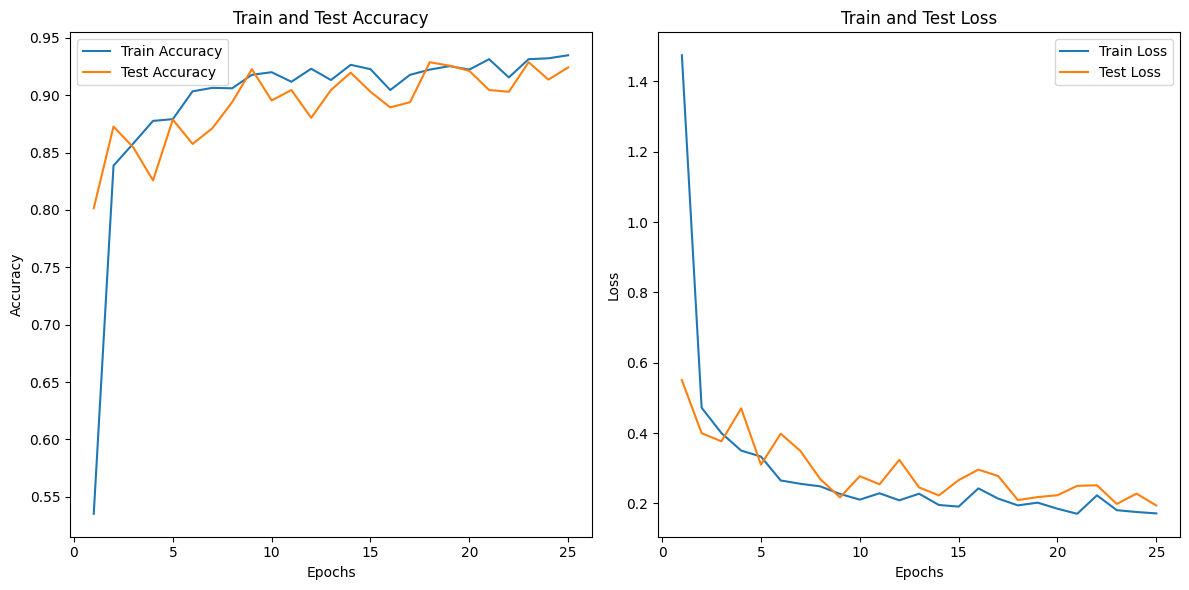

Epoch with Highest Test Accuracy: 18
Train Accuracy at Best Epoch: 0.9223
Test Accuracy at Best Epoch: 0.9288
Test Precision at Best Epoch: 0.8943
Test Recall at Best Epoch: 0.8928
Test F1-Score at Best Epoch: 0.8927
Average Training Time per Epoch: 0.38 seconds
Model Size: 0.08 MB
Number of Parameters: 21206


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.optim import Adam
import numpy as np
import time

# Assuming best_params and data loaders are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Initialize model with best parameters
model = CropCNN(
    input_shape=(1, 2, 4),
    num_classes=len(label_encoder.classes_),
    num_layers=best_params['num_layers'],
    init_channels=best_params['init_channels'],
    kernel_size=best_params['kernel_size']
)

optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Track metrics for plotting
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []
epoch_times = []

# Calculate the number of parameters and model size
num_parameters = sum(p.numel() for p in model.parameters())
model_size = sum(p.element_size() * p.numel() for p in model.parameters()) / 1e6  # Convert to MB

# Training and evaluation loop
for epoch in range(best_params['epochs']):
    start_time = time.time()  # Start timing the epoch

    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

    end_time = time.time()  # End timing the epoch
    epoch_times.append(end_time - start_time)

# Calculate average training time per epoch
avg_epoch_time = sum(epoch_times) / len(epoch_times)

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnn.png', transparent=True)  # Save the plot as an image file
plt.show()

# Find the epoch with the highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Get the corresponding train and test accuracy for that epoch
best_train_accuracy = train_accuracies[best_epoch]
best_test_accuracy = test_accuracies[best_epoch]

# Calculate precision, recall, and F1-score for the best epoch
test_precision = precision_score(all_targets, all_predictions, average="macro", zero_division=1)
test_recall = recall_score(all_targets, all_predictions, average="macro", zero_division=1)
test_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=1)

# Print the results
print(f"Epoch with Highest Test Accuracy: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best Epoch: {best_test_accuracy:.4f}")
print(f"Test Precision at Best Epoch: {test_precision:.4f}")
print(f"Test Recall at Best Epoch: {test_recall:.4f}")
print(f"Test F1-Score at Best Epoch: {test_f1:.4f}")
print(f"Average Training Time per Epoch: {avg_epoch_time:.2f} seconds")
print(f"Model Size: {model_size:.2f} MB")
print(f"Number of Parameters: {num_parameters}")


In [ ]:
from sklearn.metrics import classification_report

# Assuming all_targets and all_predictions contain the true and predicted values for the entire validation set

# Generate the classification report
report = classification_report(all_targets, all_predictions, target_names=label_encoder.classes_,digits=3)

# Print the classification report
print("Classification Report:\n", report)

Classification Report:
                   precision    recall  f1-score   support

       Aman Rice      0.659     0.648     0.654       750
       Aush Rice      0.828     0.828     0.828       750
            Bean      0.648     0.643     0.645       750
       Boro Rice      0.731     0.811     0.769       750
        Calabash      0.996     0.993     0.995       750
     Cauliflower      0.959     0.979     0.969       750
Colocasia leaves      0.974     0.893     0.932       750
            Corn      0.803     0.664     0.727       750
        Eggplant      0.921     0.913     0.917       750
            Jute      0.946     0.909     0.927       750
       Leafy Veg      0.838     0.952     0.891       750
        Oil crop      0.830     0.848     0.839       750
           Onion      0.995     0.992     0.993       750
          Papaya      0.995     1.000     0.997       750
          Peanut      0.777     0.873     0.822       750
       Pineapple      1.000     1.000     1.000

Review

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 21.2 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

class CropCNN(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size):
        super(CropCNN, self).__init__()
        self.convs = nn.ModuleList()
        self.pools = nn.ModuleList()
        in_channels = 1  # Tabular data reshaped to (1, 3, 3)

        # Compute the final output size after convolutions
        height, width = input_shape[1], input_shape[2]

        for _ in range(num_layers):
            padding = (kernel_size - 1) // 2  # Same padding
            self.convs.append(nn.Conv2d(in_channels, init_channels, kernel_size, padding=padding))
            self.pools.append(nn.MaxPool2d(2))  # Add pooling after convolution
            in_channels = init_channels
            init_channels *= 2  # Double channels with each layer

            # Update height and width after each convolution
            height = (height - kernel_size + 2 * padding) + 1
            width = (width - kernel_size + 2 * padding) + 1
            height = height // 2  # After pooling
            width = width // 2    # After pooling

            # Avoid too much shrinking
            if height <= 1 or width <= 1:
                break  # Stop if the size shrinks too much

        # After the final convolution layer, calculate the flattened size
        self.flattened_size = in_channels * height * width
        self.fc = nn.Linear(self.flattened_size, num_classes)

    def forward(self, x):
        for conv, pool in zip(self.convs, self.pools):
            x = F.relu(conv(x))
            x = pool(x)  # Apply max pooling
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc(x)
        return x


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import optuna

# Set random seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Load dataset
df = pd.read_excel("New Final DataSet Without Sulphur.xlsx", engine='openpyxl')

# Select numerical columns for scaling (remove 'S')
columns_to_scale = ['N', 'P', 'K', 'pH', 'Temp(°C)', 'Humidity(%)', 'Moisture(%)', 'Rainfall(cm)']
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Encode the target variable
label_encoder = LabelEncoder()
df_scaled['label_encoded'] = label_encoder.fit_transform(df_scaled['Crop'])
df_scaled.drop(columns=['Crop'], inplace=True)

# Prepare features and labels
X = df_scaled.drop(columns=['label_encoded']).values
y = df_scaled['label_encoded'].values

# Reshape X to 2x4 grid based on the number of features
X = X.reshape(-1, 1, 2, 4)  # Reshape into a 2x4 grid (8 features)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convert data to PyTorch tensors
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Define CNN model (without BiLSTM)
class CropCNN(nn.Module):
    def __init__(self, input_shape, num_classes, num_layers, init_channels, kernel_size):
        super(CropCNN, self).__init__()
        self.num_layers = num_layers
        self.convs = nn.ModuleList()

        # CNN layers
        for i in range(num_layers):
            in_channels = 1 if i == 0 else init_channels
            self.convs.append(
                nn.Conv2d(in_channels, init_channels, kernel_size=kernel_size, padding=1)
            )

        # Calculate the output size after passing through CNN layers
        self.conv_output_size = self._get_conv_output_size(input_shape)

        # Fully connected layer
        self.fc = nn.Linear(self.conv_output_size, num_classes)

    def _get_conv_output_size(self, input_shape):
        # Test a dummy input through the CNN layers to get the output size
        dummy_input = torch.zeros(1, *input_shape)
        x = dummy_input
        for conv in self.convs:
            x = F.relu(conv(x))
        return x.view(1, -1).size(1)  # Flatten and return the number of features

    def forward(self, x):
        for conv in self.convs:
            x = F.relu(conv(x))

        x = x.view(x.size(0), -1)  # Flatten before fully connected layer
        x = self.fc(x)
        return x

# Define Optuna objective function for CNN model
def objective(trial):
    num_layers = trial.suggest_int('num_layers', 1, 3)
    init_channels = trial.suggest_categorical('init_channels', [16, 32, 64])
    kernel_size = trial.suggest_int('kernel_size', 2, 3)
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
    epochs = trial.suggest_int('epochs', 10, 30)

    model = CropCNN(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                    num_layers=num_layers, init_channels=init_channels,
                    kernel_size=kernel_size)
    optimizer = Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # Validation Accuracy
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_predictions.extend(predicted.tolist())
            all_targets.extend(y_batch.tolist())

    accuracy = accuracy_score(all_targets, all_predictions)
    return accuracy

# Run Optuna optimization
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20)

# Get the best parameters
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2025-07-15 17:47:24,977] A new study created in memory with name: no-name-b19385bc-5a84-4469-9135-d7d8637ceb52
/tmp/ipython-input-12-4006989724.py:90: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-07-15 17:47:27,973] Trial 0 finished with value: 0.7424242424242424 and parameters: {'num_layers': 2, 'init_channels': 16, 'kernel_size': 2, 'lr': 0.00020511104188433984, 'epochs': 11}. Best is trial 0 with value: 0.7424242424242424.
/tmp/ipython-input-12-4006989724.py:90: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-4, 1e-2)
[I 2025-07-15 17:47:32,729] Trial 1 finished with valu

Best hyperparameters: {'num_layers': 2, 'init_channels': 32, 'kernel_size': 2, 'lr': 0.0021223297272287135, 'epochs': 16}


In [ ]:
best_params = {
    'num_layers': 2,
    'init_channels': 32,
    'kernel_size': 2,
    'lr': 0.008133728243728402,
    'epochs': 25
}


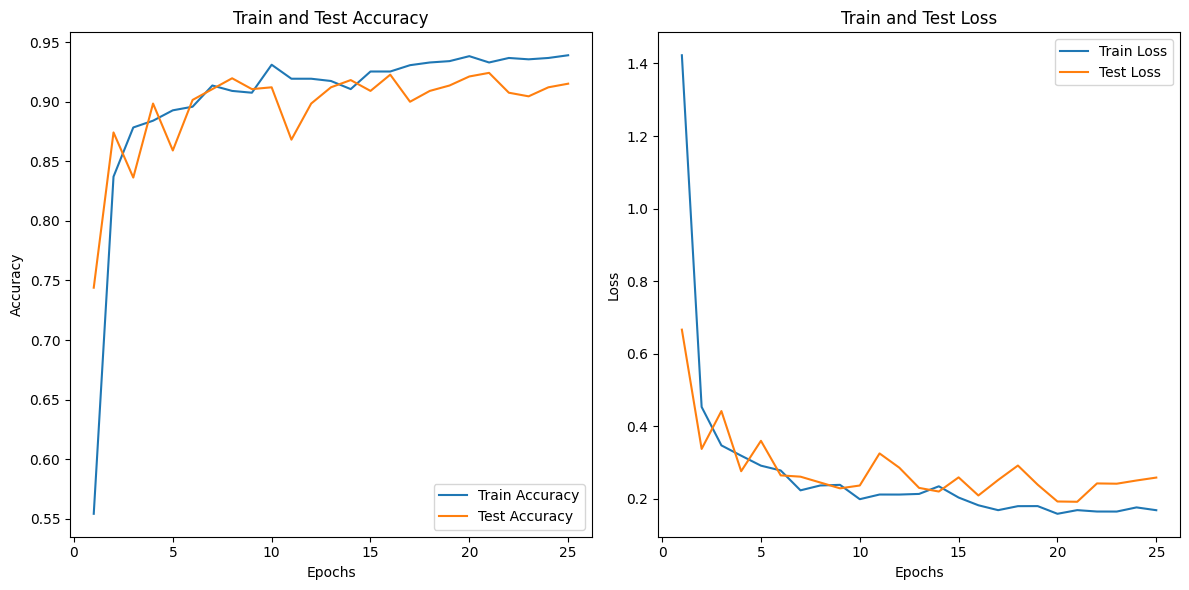

Epoch with Highest Test Accuracy: 21
Train Accuracy at Best Epoch: 0.9330
Test Accuracy at Best Epoch: 0.9242
Test Precision at Best Epoch: 0.8970
Test Recall at Best Epoch: 0.8961
Test F1-Score at Best Epoch: 0.8962


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.optim import Adam
import numpy as np

# Assuming best_params and data loaders are already defined
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# Initialize model with best parameters
model = CropCNN(input_shape=(1, 2, 4), num_classes=len(label_encoder.classes_),
                      num_layers=best_params['num_layers'], init_channels=best_params['init_channels'],
                      kernel_size=best_params['kernel_size']
                      )

optimizer = Adam(model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# Track metrics for plotting
train_accuracies, test_accuracies = [], []
train_losses, test_losses = [], []
all_targets, all_predictions = [], []

# Ensure reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

# Training and evaluation loop
for epoch in range(best_params['epochs']):
    model.train()
    train_correct, train_total, running_train_loss = 0, 0, 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += y_batch.size(0)
        train_correct += (predicted == y_batch).sum().item()

    train_accuracy = train_correct / train_total
    train_accuracies.append(train_accuracy)
    train_losses.append(running_train_loss / len(train_loader))

    # Validation
    model.eval()
    test_correct, test_total, running_test_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()
            all_targets.extend(y_batch.tolist())
            all_predictions.extend(predicted.tolist())

    test_accuracy = test_correct / test_total
    test_accuracies.append(test_accuracy)
    test_losses.append(running_test_loss / len(test_loader))

# Plot train/test accuracy and loss
epochs = range(1, best_params['epochs'] + 1)

plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.title('Train and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, test_losses, label='Test Loss')
plt.title('Train and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnn.png', transparent=True)  # Save the plot as an image file
plt.show()

# Find the epoch with the highest test accuracy
best_epoch = test_accuracies.index(max(test_accuracies))

# Get the corresponding train and test accuracy for that epoch
best_train_accuracy = train_accuracies[best_epoch]
best_test_accuracy = test_accuracies[best_epoch]

# Calculate precision, recall, and F1-score for the best epoch
test_precision = precision_score(all_targets, all_predictions, average="macro", zero_division=1)
test_recall = recall_score(all_targets, all_predictions, average="macro", zero_division=1)
test_f1 = f1_score(all_targets, all_predictions, average="macro", zero_division=1)

# Print the results
print(f"Epoch with Highest Test Accuracy: {best_epoch + 1}")
print(f"Train Accuracy at Best Epoch: {best_train_accuracy:.4f}")
print(f"Test Accuracy at Best Epoch: {best_test_accuracy:.4f}")
print(f"Test Precision at Best Epoch: {test_precision:.4f}")
print(f"Test Recall at Best Epoch: {test_recall:.4f}")
print(f"Test F1-Score at Best Epoch: {test_f1:.4f}")


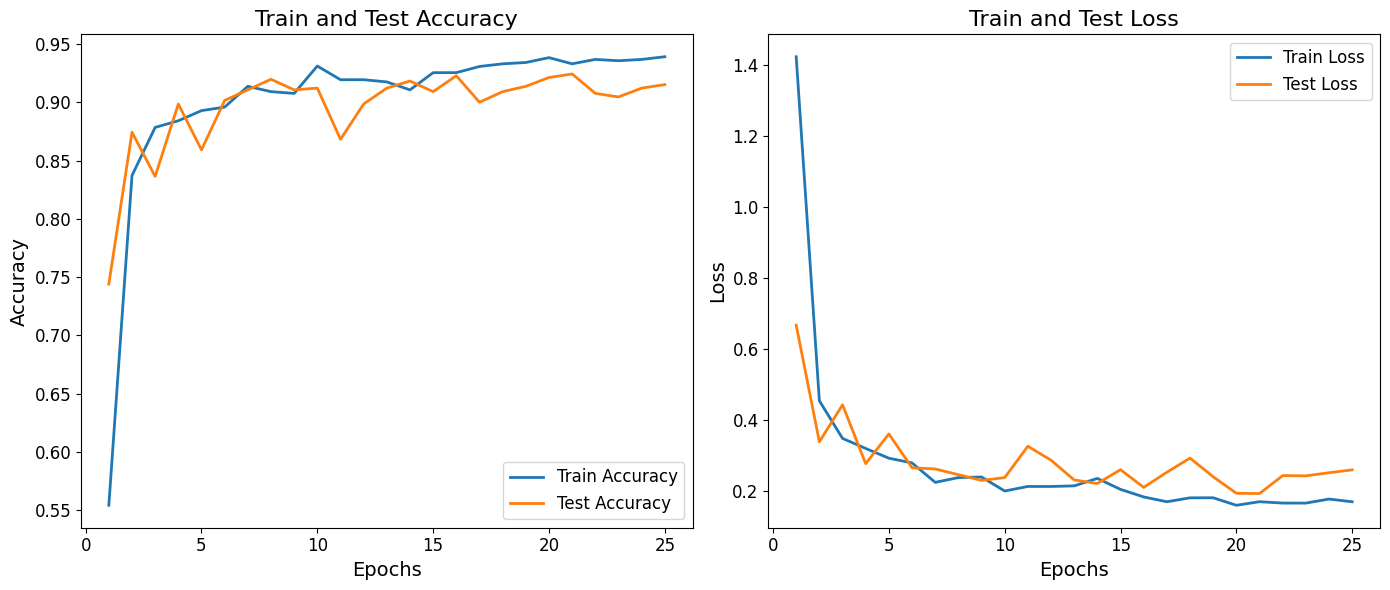

In [ ]:
plt.figure(figsize=(14, 6))  # Wider figure for better spacing

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(epochs, test_accuracies, label='Test Accuracy', linewidth=2)
plt.title('Train and Test Accuracy', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses, label='Train Loss', linewidth=2)
plt.plot(epochs, test_losses, label='Test Loss', linewidth=2)
plt.title('Train and Test Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.savefig('cnn.png', dpi=600, transparent=True)  # High-res image
plt.show()
